# MVP Análise de Dados e Boas Práticas

**Nome:** Felipe Ramos Pinheiro  
**Matrícula:** 2026000

**Fonte dos dados (neste notebook):** consulta na camada *gold* do projeto 100cep_gateway (Databricks SQL Warehouse), carregada via API do Databricks a partir do Google Colab.


# Descrição do Problema

Os dados representam transações/pedidos de uma operação de e-commerce (cenário de negócio do projeto **100cep_gateway**).

Neste MVP, o foco é:
- Realizar uma **análise exploratória (EDA)** para entender distribuição e relações entre variáveis;
- Preparar um conjunto de dados pronto para modelagem, com **pré-processamento reprodutível**;
- Estruturar `X` (features) e `y` (target), onde `y = tipo_pagamento`.

O objetivo do modelo é prever o tipo_pagamento de uma transação a partir das demais variáveis disponíveis no recorte de dados.


## Hipóteses do Problema

As hipóteses avaliadas ao longo da EDA são:

1. **O valor da transação varia por região/estado?** (comparação por `regiao`/`estado`).
2. **O tipo de pagamento está associado a padrões de valor/frete e ao `status_pedido`?**
3. **Há relação entre variáveis numéricas (`valor_transacao`, `preco_total`, `frete_total`) e o `status_pedido`?**


## Tipo de Problema

Do ponto de vista de modelagem, este notebook estrutura um problema **supervisionado de classificação**, usando:

- **Target (`y`)**: `tipo_pagamento`
- **Features (`X`)**: variáveis numéricas e categóricas



## Seleção de Dados

Os dados analisados aqui são obtidos diretamente do **Databricks SQL Warehouse** (via API) a partir de uma consulta que junta:
- `100cep_gateway.gold.fato_transacoes`
- `100cep_gateway.gold.dim_clientes`
- `100cep_gateway.gold.dim_geolocalizacao`

A autenticação é feita por **Secrets do Google Colab**:
- `DATABRICKS_HOST`
- `API_TOKEN`
- `WAREHOUSE_ID`

Esse recorte é a base para todas as etapas de EDA e pré-processamento.


## Atributos do Dataset

| Coluna | Tipo | Descrição |
| ------ | ---- | --------- |
| `cliente_id` | string | Identificador do cliente. |
| `pedido_id` | string | Identificador do pedido. |
| `data_pedido` | datetime | Data/hora do pedido. |
| `estado` | string | UF associada ao CEP. |
| `cidade` | string | Cidade associada ao CEP. |
| `valor_transacao` | float | Valor da transação. |
| `frete_total` | float | Total do frete. |
| `preco_total` | float | Preço total do pedido. |
| `tipo_pagamento` | string | Método de pagamento. |
| `status_pedido` | string | Status do pedido (target). |

Além disso, criamos uma variável derivada:
- `regiao`: mapeada a partir da UF (`estado`).


# Importação das Bibliotecas Necessárias e Carga de Dados

Nesta seção:
1. Instalação das dependências no **Google Colab** (`%pip`).
2. Importação bibliotecas de análise e *machine learning*.
3. Leitura do recorte de dados via **Databricks SQL API** para geração o DataFrame `df`.
4. Realização conversões de tipos (incluindo `data_pedido` para datetime).
5. Criação a coluna `regiao` a partir do mapeamento de UF.


In [ ]:
# Instalar dependencias
%pip -q install pandas numpy scikit-learn seaborn matplotlib requests


In [ ]:
import requests
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from google.colab import userdata


In [ ]:
# Conexão no Databricks
try:
    DATABRICKS_HOST = userdata.get('DATABRICKS_HOST')
    TOKEN = userdata.get('API_TOKEN')
    WAREHOUSE_ID = userdata.get('WAREHOUSE_ID')
except Exception as e:
    print(
        "Erro: Secret nao encontrado. Configure 'DATABRICKS_HOST', 'API_TOKEN' e 'WAREHOUSE_ID' no Colab (Secrets)."
    )
    raise

if DATABRICKS_HOST and not DATABRICKS_HOST.startswith(('http://', 'https://')):
    DATABRICKS_HOST = f"https://{DATABRICKS_HOST}"

headers = {
    "Authorization": f"Bearer {TOKEN}",
    "Content-Type": "application/json"
}

# Recorte do Dataset que será utilizado
query = {
    "statement": """
SELECT
  cliente_id,
  pedido_id,
  data_pedido,
  estado,
  cidade,
  valor_transacao,
  frete_total,
  preco_total,
  tipo_pagamento,
  status_pedido
FROM
  100cep_gateway.gold.fato_transacoes
LEFT JOIN
  100cep_gateway.gold.dim_clientes
  USING(cliente_id)
LEFT JOIN
  100cep_gateway.gold.dim_geolocalizacao
  USING(cep_prefixo)
GROUP BY ALL""",
    "warehouse_id": WAREHOUSE_ID
}

response = requests.post(
    f"{DATABRICKS_HOST}/api/2.0/sql/statements",
    headers=headers,
    json=query
)

result = response.json()
if "statement_id" not in result:
    print("Erro na resposta da API:", result)
    raise Exception("Nao foi possivel iniciar a query.")

statement_id = result["statement_id"]

while True:
    res = requests.get(
        f"{DATABRICKS_HOST}/api/2.0/sql/statements/{statement_id}",
        headers=headers
    ).json()

    state = res["status"]["state"]

    if state == "SUCCEEDED":
        break
    if state in ["FAILED", "CANCELED"]:
        raise Exception(f"Query falhou com estado: {state}")

    time.sleep(2)

data = res["result"]["data_array"]
columns = [col["name"] for col in res["manifest"]["schema"]["columns"]]

df = pd.DataFrame(data, columns=columns)

# Conversao de tipos de dados

tipos = {
    'cliente_id': str,
    'pedido_id': str,
    'data_pedido': 'datetime64[ns]',
    'estado': str,
    'cidade': str,
    'valor_transacao': float,
    'frete_total': float,
    'preco_total': float,
    'tipo_pagamento': str,
    'status_pedido': str,
}

for coluna, tipo in tipos.items():
    if tipo == 'datetime64[ns]':
        df[coluna] = pd.to_datetime(df[coluna], errors='coerce')
    else:
        df[coluna] = df[coluna].astype(tipo)

brazilian_regions = {
    'AC': 'NORTE', 'AM': 'NORTE', 'AP': 'NORTE', 'PA': 'NORTE', 'RO': 'NORTE', 'RR': 'NORTE', 'TO': 'NORTE',
    'AL': 'NORDESTE', 'BA': 'NORDESTE', 'CE': 'NORDESTE', 'MA': 'NORDESTE', 'PB': 'NORDESTE', 'PE': 'NORDESTE', 'PI': 'NORDESTE', 'RN': 'NORDESTE', 'SE': 'NORDESTE',
    'DF': 'CENTRO-OESTE', 'GO': 'CENTRO-OESTE', 'MS': 'CENTRO-OESTE', 'MT': 'CENTRO-OESTE',
    'ES': 'SUDESTE', 'MG': 'SUDESTE', 'RJ': 'SUDESTE', 'SP': 'SUDESTE',
    'PR': 'SUL', 'RS': 'SUL', 'SC': 'SUL',
    'None':'INTERNACIONAL'
}

df['regiao'] = df['estado'].map(brazilian_regions)

# Remover pedidos Internacionais
df = df[df['regiao'] != 'INTERNACIONAL']

display(df.head())


,cliente_id,pedido_id,data_pedido,estado,cidade,valor_transacao,frete_total,preco_total,tipo_pagamento,status_pedido,regiao
0,a5363e7315ac0091e716040860cfc833,fed058642b519335c834d73b851e20d0,2018-01-05,CE,ALTO SANTO,159.30,29.31,129.99,CARTAO DE CREDITO,ENTREGUE,NORDESTE
1,bab0097a6b5e99f6b73299e7e1c79a6e,5f149cfaf9ec98e580e5cf5e000b5aaa,2018-04-20,SP,ARACATUBA,68.37,14.47,53.90,CARTAO DE CREDITO,ENTREGUE,SUDESTE
2,052451bf64a77a9180aef297df1f2020,d4a82e0a8772db180275f4160d9eb12d,2017-07-25,SP,ARACATUBA,74.16,15.16,59.00,CARTAO DE CREDITO,ENTREGUE,SUDESTE
3,ed2477fdffb22d49fd5485a80041ed09,69294a1f2dbe29a54c3a9c2421831d14,2018-08-03,SP,ASSIS,76.01,14.01,62.00,CARTAO DE CREDITO,ENTREGUE,SUDESTE
4,5d0a0ccfb50f5dd07398cfae09297925,5a0338c421599254813c9ab9d9c3dc2f,2017-04-24,SP,AVARE,208.07,18.17,189.90,CARTAO DE CREDITO,ENTREGUE,SUDESTE


# Análise de Dados

A EDA tem como objetivo:
- Entender o volume e tipos de dados;
- Analisar distribuição e dispersão das variáveis numéricas;
- Verificar correlações e relações entre variáveis;
- Apoiar decisões de pré-processamento (missing values, escala, outliers).


## Total e Tipo das Instâncias

Nesta etapa, inspecionamos:
- Total de instâncias (`len(df)`)
- Esquema e tipos de dados (`df.info()`)

Isso confirma quais colunas são numéricas/categóricas e se as conversões aplicadas na carga estão corretas.


In [ ]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 30473

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
Index: 30473 entries, 0 to 30556
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   cliente_id       30473 non-null  object        
 1   pedido_id        30473 non-null  object        
 2   data_pedido      30473 non-null  datetime64[ns]
 3   estado           30473 non-null  object        
 4   cidade           30473 non-null  object        
 5   valor_transacao  30473 non-null  float64       
 6   frete_total      30473 non-null  float64       
 7   preco_total      30473 non-null  float64       
 8   tipo_pagamento   30473 non-null  object        
 9   status_pedido    30473 non-null  object        
 10  regiao           30473 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 2.8+ MB
None


## Estatísticas Descritivas

Utilização da `df.describe()` para resumir variáveis numéricas (média, desvio padrão, quartis, mínimo e máximo).
Esse resumo ajuda a identificar:
- Escalas muito diferentes entre features;
- Assimetria/caudas longas;
- Possíveis outliers.


In [ ]:
df.describe()

,data_pedido,valor_transacao,frete_total,preco_total
count,30473,30473.000000,30473.000000,30473.000000
mean,2017-12-30 10:31:30.906704384,154.649901,22.964850,138.405740
min,2016-10-03 00:00:00,0.000000,0.000000,0.850000
25%,2017-09-13 00:00:00,57.510000,13.930000,45.900000
50%,2018-01-18 00:00:00,100.700000,17.320000,87.500000
75%,2018-05-03 00:00:00,173.090000,24.380000,149.990000
max,2018-08-29 00:00:00,6726.660000,626.640000,6499.000000
std,NaN,213.875679,20.944976,210.262941


### Média

A média é uma medida de tendência central calculada pela soma dos valores dividida pelo total de observações.

No contexto deste dataset, ela é útil para ter um “valor típico”, mas deve ser interpretada com cuidado quando há assimetria e outliers.


In [ ]:
df.describe().loc['mean']

,mean
data_pedido,2017-12-30 10:31:30.906704384
valor_transacao,154.649901
frete_total,22.96485
preco_total,138.40574


### Desvio Padrão

O desvio padrão mede dispersão em torno da média.

Em variáveis financeiras como `valor_transacao`, `frete_total` e `preco_total`, um desvio padrão alto pode indicar grande heterogeneidade (e potencial presença de valores extremos).


In [ ]:
df.describe().loc['std']

,std
data_pedido,NaN
valor_transacao,213.875679
frete_total,20.944976
preco_total,210.262941


## Histograma

Histogramas ajudam a visualizar a distribuição das variáveis.

Aqui, foi analisado principalmente `valor_transacao` usando diferentes números de *bins* e KDE, ajustando o eixo x para focar na faixa mais representativa (recorte por quantis).


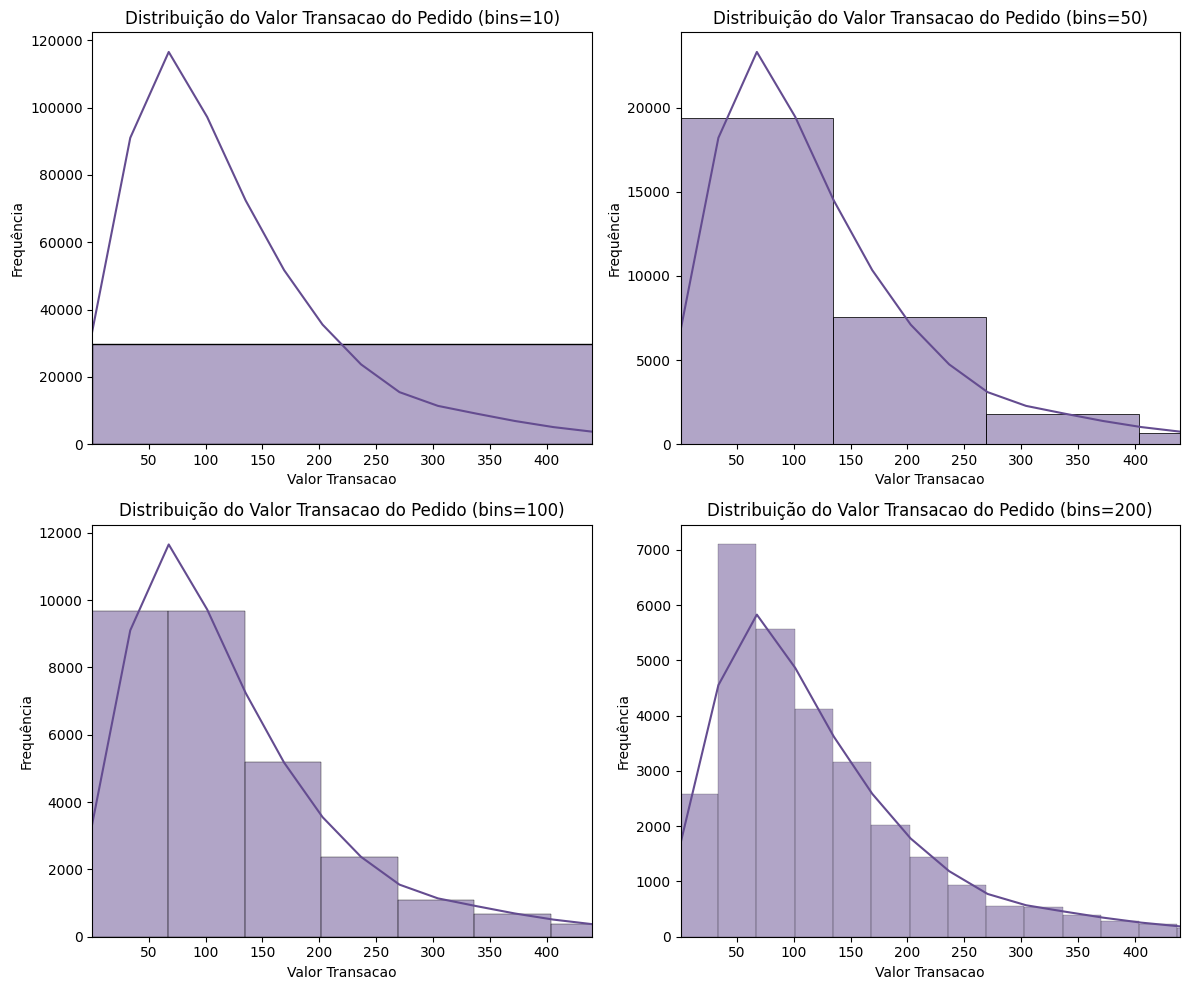

In [ ]:
# Lista com diferentes quantidades de bins
bins_list = [10, 50, 100, 200]

# Cria a figura com subplots (2x2 neste caso)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # facilita iteração

for i, bins in enumerate(bins_list):
    sns.histplot(df['valor_transacao'], kde=True, bins=bins, ax=axes[i], color = '#644c90')
    lower_bound = df['valor_transacao'].quantile(0.001)
    upper_bound = df['valor_transacao'].quantile(0.95)
    axes[i].set_xlim(lower_bound, upper_bound)
    axes[i].set_title(f'Distribuição do Valor Transacao do Pedido (bins={bins})')
    axes[i].set_xlabel('Valor Transacao')
    axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

O histograma apresenta a distribuição de `valor_transacao` para diferentes quantidades de *bins*.

Para melhorar a leitura, o gráfico ajusta o eixo x para a região onde está a maior parte dos dados (por exemplo, entre os quantis 0.1% e 95%), reduzindo o impacto visual de caudas muito longas.

A distribuição de `valor_transacao` é claramente assimétrica à direita (cauda longa). A maior parte dos pedidos se concentra em valores mais baixos (aprox. entre ~40 e ~150), enquanto existe um conjunto menor de transações com valores bem mais altos, que alonga a cauda.

Importante ressaltar que as médias podem ficar infladas por extremos e modelos sensíveis à escala podem ser dominados por outliers.



## Boxplot

Boxplots permitem comparar distribuições e identificar assimetrias.

Nesta seção, usei boxplots para comparar `valor_transacao` entre grupos (por exemplo, por `tipo_pagamento`) e utilizamos `showfliers=False` para não deixar outliers dominarem a escala visual.

Ao segmentar por `tipo_pagamento`, fica mais fácil ver diferenças de ticket médio, dispersão e possíveis perfis de compra por categoria.

O objetivo é observar diferenças de mediana, dispersão e possíveis padrões para cada método de pagamento.

In [ ]:
df.groupby('tipo_pagamento').describe()

data_pedido                                 \
                        count                           mean   
tipo_pagamento                                                 
BOLETO                   5799  2017-12-21 18:21:47.397827072   
CARTAO DE CREDITO       22675  2018-01-02 08:54:31.832414720   
CARTAO DE DEBITO          455  2018-03-12 16:40:05.274725376   
VOUCHER                  1544  2017-11-28 15:40:06.217616640   

                                                             \
                                   min                  25%   
tipo_pagamento                                                
BOLETO             2016-10-03 00:00:00  2017-08-30 00:00:00   
CARTAO DE CREDITO  2016-10-03 00:00:00  2017-09-18 00:00:00   
CARTAO DE DEBITO   2017-01-19 00:00:00  2017-12-14 00:00:00   
VOUCHER            2016-10-04 00:00:00  2017-07-22 18:00:00   

                                                             \
                                   50%                  75%   
tipo_pagamento                                                
BOLETO             2018-01-08 00:00:00  2018-04-27 00:00:00   
CARTAO DE CREDITO  2018-01-22 00:00:00  2018-05-05 00:00:00   
CARTAO DE DEBITO   2018-04-24 00:00:00  2018-07-20 00:00:00   
VOUCHER            2017-12-12 00:00:00  2018-04-06 12:00:00   

                                            valor_transacao              ...  \
                                   max  std           count        mean  ...   
tipo_pagamento                                                           ...   
BOLETO             2018-08-27 00:00:00  NaN          5799.0  143.945554  ...   
CARTAO DE CREDITO  2018-08-29 00:00:00  NaN         22675.0  162.933847  ...   
CARTAO DE DEBITO   2018-08-27 00:00:00  NaN           455.0  157.365429  ...   
VOUCHER            2018-08-29 00:00:00  NaN          1544.0   72.396315  ...   

                  frete_total            preco_total                           \
                          max        std       count        mean   min    25%   
tipo_pagamento                                                                  
BOLETO                 497.08  21.701787      5799.0  121.122012  0.85  39.99   
CARTAO DE CREDITO      626.64  20.964213     22675.0  143.791574  0.85  49.00   
CARTAO DE DEBITO       129.74  15.319072       455.0  136.710154  8.49  39.90   
VOUCHER                208.00  19.103440      1544.0  124.724424  3.54  39.00   

                                                       
                    50%       75%     max         std  
tipo_pagamento                                         
BOLETO             76.0  135.0000  6499.0  206.452718  
CARTAO DE CREDITO  89.9  159.0000  4799.0  209.434438  
CARTAO DE DEBITO   79.0  139.7850  4400.0  322.008454  
VOUCHER            69.9  131.2275  2649.0  190.091197  

[4 rows x 32 columns]

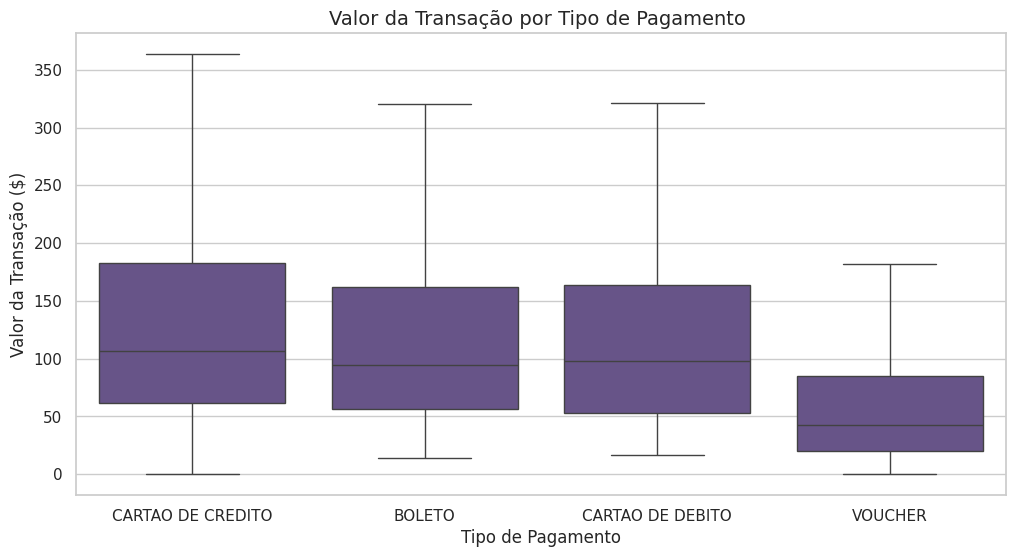

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.boxplot(
    x='tipo_pagamento',
    y='valor_transacao',
    data=df,
    showfliers=False,
    color= '#644c90',
)


plt.title('Valor da Transação por Tipo de Pagamento ', fontsize=14)
plt.xlabel('Tipo de Pagamento')
plt.ylabel('Valor da Transação ($)')

plt.show()

Ao analisar o Boxplot, observamos que o `VOUCHER` tende a concentrar transações de menor valor (mediana mais baixa e menor amplitude), enquanto `CARTAO DE CREDITO` apresenta valores típicos mais altos e maior dispersão. `BOLETO` e `CARTAO DE DEBITO` ficam próximos entre si.

Importante ressaltar que o padrão pode refletir perfil de compra (ex.: voucher associado a promoções/cestas menores), e não causalidade; para modelagem com `tipo_pagamento` como *target*, essa separação sugere que variáveis de valor podem ter poder preditivo, mas exigem cuidado com outliers e com eventual “proxy” de políticas comerciais.


## Matriz de Correlação

A matriz de correlação mostra a relação linear entre variáveis numéricas.

Foi analisado a correlação das seguintes métricas:
- `valor_transacao`
- `preco_total`
- `frete_total`

Valores próximos de 1 indicam correlação positiva forte; próximos de -1, negativa forte; e próximos de 0, pouca relação linear.



Matriz de Correlação:


<Axes: >

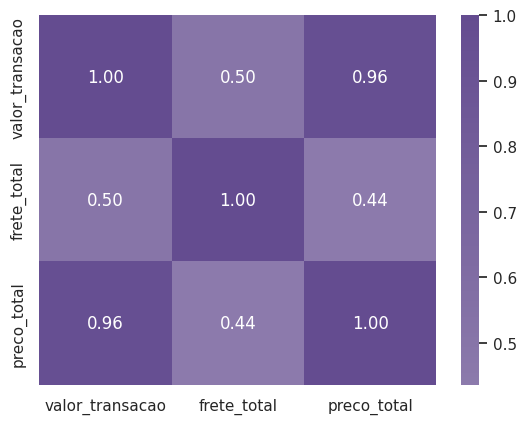

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=sns.light_palette("#644c90", as_cmap=True), fmt = ".2f", center = 0)

Podemos concluír, a partir da matriz, que as variáveis `valor_transacao` e `preco_total` apresentam correlação muito forte (~0,96). Esta forte correlação sugere que as métricas carregam informação bastante redundante (o valor da transação acompanha de perto o preço total).

Por outro lado, `frete_total` tem correlação moderada com `valor_transacao` (~0,50) e mais baixa com `preco_total` (~0,44), indicando que o frete agrega variação adicional, mas não explica sozinho o valor.

<Axes: xlabel='valor_transacao', ylabel='preco_total'>

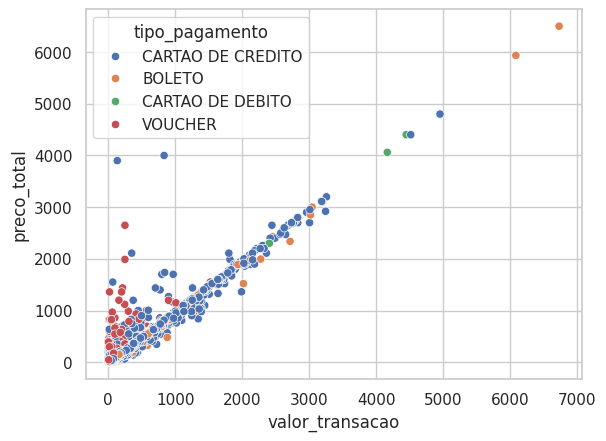

In [ ]:
sns.scatterplot(data=df, x='valor_transacao', y='preco_total', hue='tipo_pagamento')

O scatterplot reforça uma relação quase linear entre `valor_transacao` e `preco_total`, com a maioria dos pontos concentrada em valores baixos e poucos casos extremos (transações muito altas) afastados do “miolo” da nuvem.

As cores por `tipo_pagamento` não sugerem mudança clara de inclinação, mas podem indicar diferenças de densidade/ocorrência por faixa de valores.

As informações são úteis para entender a redundância entre as observações e orientar escolhas de pré processamento e modelagem.

## Tratamento de Valores Nulos

O tratamento de valores nulos é uma etapa importante na preparação de dados para aprendizado supervisionado, pois a maioria dos algoritmos de machine learning não consegue processar dados incompletos ou falha ao lidar com eles, resultando em erros ou modelos com baixa precisão.

Nesta seção foram verificados os valores nulos por coluna;


In [ ]:
# Verificar valores nulos no dataset original
print('Valores nulos no dataset (por coluna):')
nulls = df.isnull().sum().sort_values(ascending=False)
display(nulls)


Valores nulos no dataset (por coluna):


,0
cliente_id,0
pedido_id,0
data_pedido,0
estado,0
cidade,0
valor_transacao,0
frete_total,0
preco_total,0
tipo_pagamento,0
status_pedido,0


A checagem mostra que o recorte utilizado não possui valores nulos em nenhuma das colunas. Vale ressaltar que esta etapa já foi realizada durante as etapas de modelagem de dados, no MVP anterior.

# Pré-Processamento de Dados

As principais etapas aplicadas são:

1. Definição de listas de features:
   - Numéricas: `frete_total`, `valor_transacao`, `preco_total`
   - Categóricas: `estado`, `cidade`, `tipo_pagamento`, `regiao`
2. Definição de `X` e `y` (`y = tipo_pagamento`).
3. Remoção de classes raras (classes com apenas 1 ocorrência) antes do split.
4. Split treino/teste estratificado (`train_test_split(..., stratify=y)`).
5. Tratamento de outliers **apenas no treino** (IQR) com decisão de **DROP**.
6. Transformações:
   - Escalonamento numérico (exemplos com MinMax e Standard, sempre *fit* no treino)
   - Pipeline final com imputação + padronização (num) e imputação + one-hot (cat)


In [ ]:
# Separa features (X) e target (y)

numeric_features = ['frete_total', 'valor_transacao', 'preco_total']
categorical_features = ['estado', 'cidade', 'regiao', 'status_pedido']
target_col = 'tipo_pagamento'

X = df[numeric_features + categorical_features]
y = df[target_col]


In [ ]:
# Filtra classes com apenas um membro antes de dividir os dados
rare_classes = y.value_counts()[y.value_counts() == 1].index

mask_rare = ~df[target_col].isin(rare_classes)
df_filtered = df[mask_rare]
X_filtered = df_filtered[numeric_features + categorical_features]
y_filtered = df_filtered[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.3,
    random_state=125,
    stratify=y_filtered,
)


In [ ]:
print(f'Dimensoes de X_train (antes outliers): {X_train.shape}')
print(f'Dimensoes de X_test: {X_test.shape}')
print(f'Dimensoes de y_train (antes outliers): {y_train.shape}')
print(f'Dimensoes de y_test: {y_test.shape}')

# Trata os outliers
X_train_raw = X_train.copy()
y_train_raw = y_train.copy()

q1 = X_train_raw['valor_transacao'].quantile(0.25)
q3 = X_train_raw['valor_transacao'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

inlier_mask = (X_train_raw['valor_transacao'] >= lower_bound) & (X_train_raw['valor_transacao'] <= upper_bound)

X_train = X_train_raw.loc[inlier_mask].copy()
y_train = y_train_raw.loc[inlier_mask].copy()

outliers_train = X_train_raw.loc[~inlier_mask].copy()
outliers_train[target_col] = y_train_raw.loc[~inlier_mask].values

print(f'Outliers removidos do TREINO: {(~inlier_mask).sum()} ({((~inlier_mask).mean()*100):.2f}%)')
print(f'Dimensoes de X_train (apos outliers): {X_train.shape}')
print(f'Dimensoes de y_train (apos outliers): {y_train.shape}')


Dimensoes de X_train (antes outliers): (21331, 7)
Dimensoes de X_test: (9142, 7)
Dimensoes de y_train (antes outliers): (21331,)
Dimensoes de y_test: (9142,)
Outliers removidos do TREINO: 1648 (7.73%)
Dimensoes de X_train (apos outliers): (19683, 7)
Dimensoes de y_train (apos outliers): (19683,)


## Normalização

A normalização (MinMax) escala variáveis numéricas para o intervalo [0, 1].

Boas práticas aplicadas no código:
- o scaler é ajustado (**fit**) apenas com `X_train`;
- a transformação é aplicada em `X_train` e `X_test`.


In [ ]:
# Inicializa o MinMaxScaler
scaler_norm = MinMaxScaler()


In [ ]:
# Aprende min e max apenas de X_train
scaler_norm.fit(X_train[numeric_features])
X_train_normalized = scaler_norm.transform(X_train[numeric_features])
X_test_normalized = scaler_norm.transform(X_test[numeric_features])


In [ ]:
# Exibe as primeiras linhas dos dados normalizados 
df_normalized = pd.DataFrame(X_train_normalized, columns=numeric_features)
display(df_normalized.head())


,frete_total,valor_transacao,preco_total
0,0.296697,0.385050,0.020302
1,0.044132,0.065971,0.003604
2,0.106488,0.515689,0.040571
3,0.110357,0.258091,0.017585
4,0.080581,0.650036,0.053651


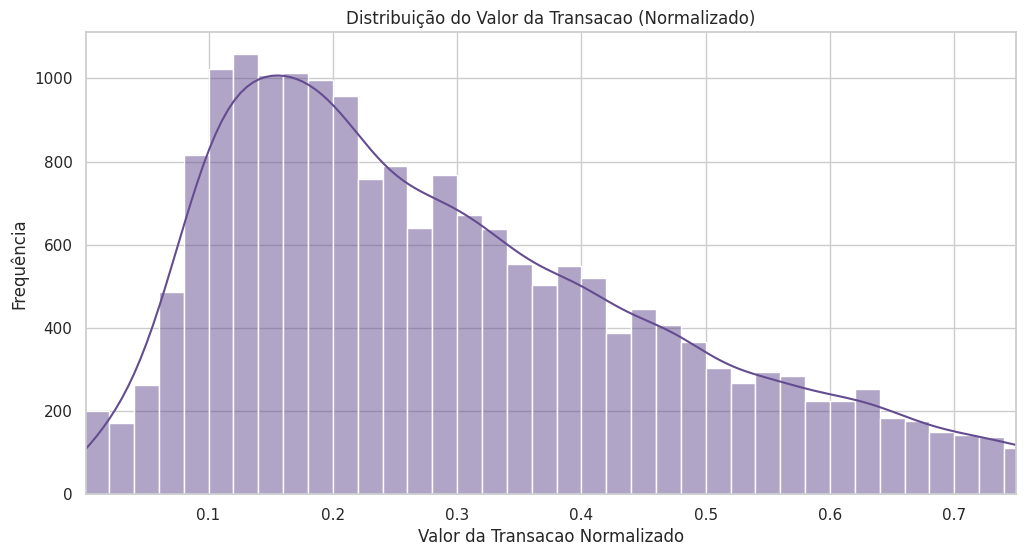

In [ ]:
# Visualização da distribuição após a normalização
plt.figure(figsize=(12, 6))
sns.histplot(df_normalized['valor_transacao'], kde=True, bins =50, color = '#644c90')
plt.title('Distribuição do Valor da Transacao (Normalizado)')
plt.xlabel('Valor da Transacao Normalizado')
plt.ylabel('Frequência')

# Ajusta os limites do eixo x para centralizar e focar na maior parte da distribuição
lower_bound = df_normalized['valor_transacao'].quantile(0.001)
upper_bound = df_normalized['valor_transacao'].quantile(0.95)
plt.xlim(lower_bound, upper_bound)

plt.show()

O histograma após a normalização mostra `valor_transacao` (do conjunto de treino) escalado para [0, 1], preservando o formato geral da distribuição.Após a normalização (MinMax), o formato da distribuição permanece assimétrico (a escala muda, a forma não). Isso confirma que a ela ajuda a colocar variáveis em uma mesma faixa, mas não “corrige” cauda longa.


## Padronização

A padronização (StandardScaler) transforma variáveis numéricas para média 0 e desvio padrão 1.

No código:
- O scaler é ajustado (**fit**) apenas no treino;
- O mesmo scaler é usado para transformar treino e teste.


In [ ]:
# Inicializa o StandardScaler
scaler_std = StandardScaler()


In [ ]:
# Aprende media e desvio padrao APENAS de X_train 
scaler_std.fit(X_train[numeric_features])
X_train_standardized = scaler_std.transform(X_train[numeric_features])
X_test_standardized = scaler_std.transform(X_test[numeric_features])


In [ ]:
# Exibe as primeiras linhas dos dados padronizados 
df_standardized = pd.DataFrame(X_train_standardized, columns=numeric_features)
display(df_standardized.head())


,frete_total,valor_transacao,preco_total
0,2.409992,0.304184,-0.205408
1,-0.945354,-1.208051,-0.993883
2,-0.116947,0.923331,0.751689
3,-0.065544,-0.297524,-0.333691
4,-0.461124,1.560055,1.369362


In [ ]:
# Pre-processamento completo com Pipeline + ColumnTransformer
# - Numericas: imputação mediana + padronização
# - Categoricas: imputação moda + One-Hot 

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print('Shape X_train_prepared:', X_train_prepared.shape)
print('Shape X_test_prepared:', X_test_prepared.shape)

try:
    feature_names = preprocessor.get_feature_names_out()
    print('N de features apos transformacao:', len(feature_names))
except Exception:
    pass


Shape X_train_prepared: (19683, 2304)
Shape X_test_prepared: (9142, 2304)
N de features apos transformacao: 2304


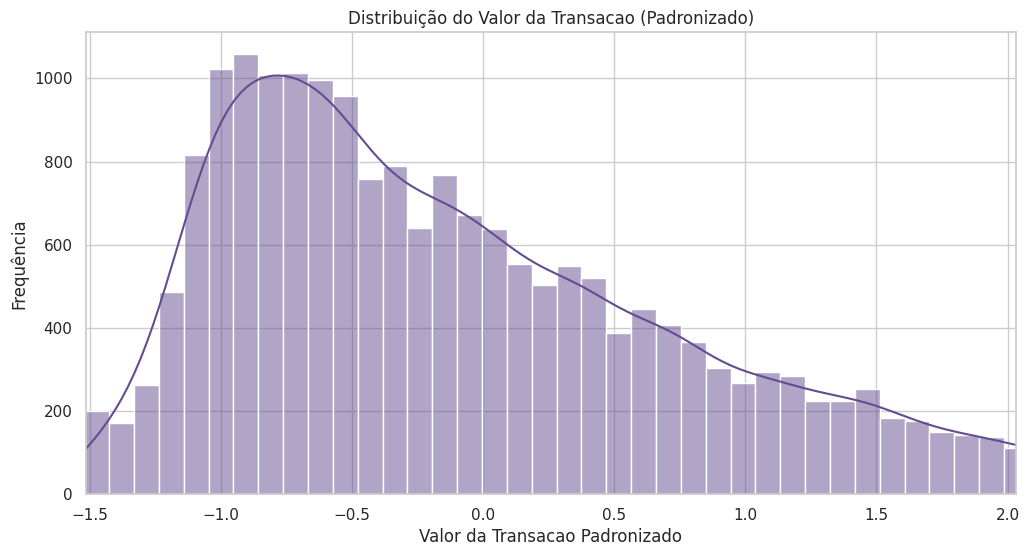

In [ ]:
# Visualização da distribuição após a padronização
plt.figure(figsize=(12, 6))
sns.histplot(df_standardized['valor_transacao'], kde=True, bins=50, color = '#644c90')
plt.title('Distribuição do Valor da Transacao (Padronizado)')
plt.xlabel('Valor da Transacao Padronizado')
plt.ylabel('Frequência')

# Ajusta os limites do eixo x para centralizar e focar na maior parte da distribuição
lower_bound = df_standardized['valor_transacao'].quantile(0.001)
upper_bound = df_standardized['valor_transacao'].quantile(0.95)
plt.xlim(lower_bound, upper_bound)

plt.show()

O histograma após a padronização mostra `valor_transacao` (no treino) centralizado em torno de 0, com escala em desvios padrão. A padronização (StandardScaler) recentra a variável (média ~0) e ajusta a escala (desvio padrão ~1), mas a assimetria e a cauda longa permanecem visíveis.


# Tratamento de Outliers

Outliers podem distorcer estatísticas e afetar transformações e modelos.

Neste notebook, o tratamento segue duas boas práticas:

1. **Cálculo dos limites no treino**: o IQR é calculado usando apenas o conjunto de treino (`X_train_raw['valor_transacao']`). Isso evita vazamento de informações do teste.
2. **Decisão: DROP no treino**: removemos do treino as linhas cujo `valor_transacao` está fora dos limites (Q1 - 1.5*IQR, Q3 + 1.5*IQR). O conjunto de teste é mantido intacto.

Também comparamos a distribuição de `valor_transacao` no treino antes vs. depois do drop para avaliar o impacto do tratamento.


In [ ]:
# Calculo do outlier (IQR) no TREINO (valor_transacao)
print('Limites (IQR) calculados no treino:')
print(f'lower_bound={lower_bound:.4f} | upper_bound={upper_bound:.4f}')


Limites (IQR) calculados no treino:
lower_bound=-1.5151 | upper_bound=2.0312


In [ ]:
print('Outliers identificados no TREINO (primeiras linhas):')
display(outliers_train[['valor_transacao', 'preco_total', 'frete_total', target_col]].head())

total_occurrences = len(X_train_raw)
percentage_outliers = (len(outliers_train) / total_occurrences) * 100

print(f'Total de ocorrencias (treino, antes drop): {total_occurrences}')
print(f'Numero de outliers (treino): {len(outliers_train)}')
print(f'Porcentagem de outliers (treino): {percentage_outliers:.2f}%')


Outliers identificados no TREINO (primeiras linhas):


,valor_transacao,preco_total,frete_total,tipo_pagamento
24179,507.90,489.9,18.00,CARTAO DE CREDITO
5011,419.06,380.0,39.06,CARTAO DE CREDITO
23479,373.55,298.8,74.75,CARTAO DE CREDITO
7511,406.23,385.0,21.23,BOLETO
21543,776.50,739.8,36.70,CARTAO DE CREDITO


Total de ocorrencias (treino, antes drop): 21331
Numero de outliers (treino): 1648
Porcentagem de outliers (treino): 7.73%


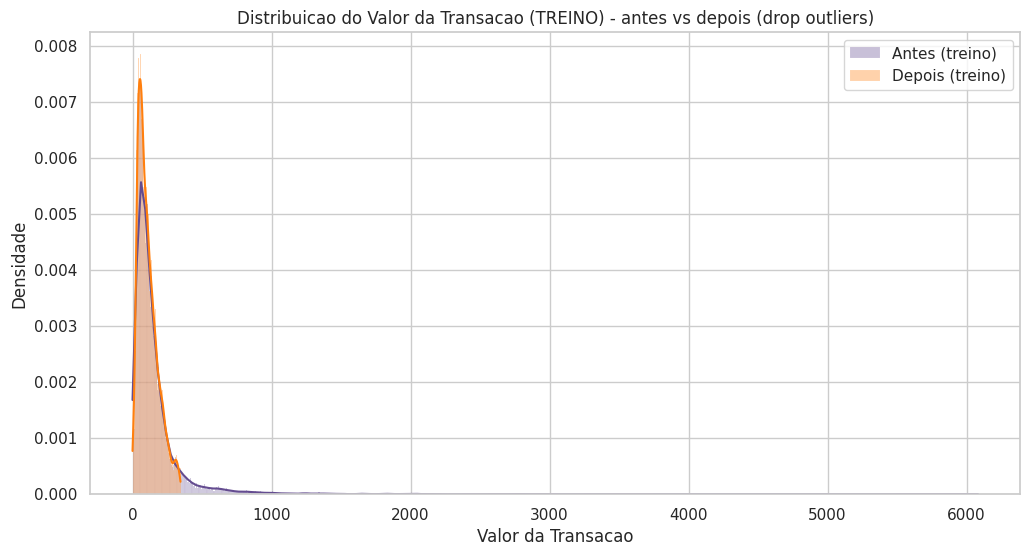

In [ ]:
# Distribuicao do valor_transacao no treino: antes vs depois do drop de outliers
plt.figure(figsize=(12, 6))
sns.histplot(X_train_raw['valor_transacao'], kde=True, label='Antes (treino)', stat='density', alpha=0.35, color = '#644c90')
sns.histplot(X_train['valor_transacao'], kde=True, color='tab:orange', label='Depois (treino)', stat='density', alpha=0.35)
plt.title('Distribuicao do Valor da Transacao (TREINO) - antes vs depois (drop outliers)')
plt.xlabel('Valor da Transacao')
plt.ylabel('Densidade')
plt.legend()
plt.show()

Ao remover outliers (IQR) no conjunto de treino, a distribuição fica mais concentrada na faixa típica e a cauda extrema perde peso, o que tende a estabilizar estatísticas (média/desvio) e a aprendizagem de modelos

# Respondendo nossas hipóteses

As hipóteses são discutidas com base em:
- estatísticas descritivas e `groupby(...).describe()` por `status_pedido`;
- boxplots comparando `valor_transacao` por `regiao`;
- matriz de correlação e scatterplot entre variáveis numéricas.

A seguir, registramos as evidências observadas nesses gráficos/tabelas.


## Hipótese 1

**O valor da transação varia por região/estado?**

Evidências utilizadas:
- Boxplot de `valor_transacao` por `regiao`
- Estatísticas descritivas por grupos


Resumo por REGIAO (valor_transacao):


,qtd,media,mediana,p25,p75
regiao,,,,,
NORTE,583,189.979057,130.220,73.7850,221.900
NORDESTE,2928,189.365454,122.030,71.1475,207.905
CENTRO-OESTE,2055,174.953985,108.900,63.1950,184.555
SUL,4234,161.470815,105.285,61.5925,180.220
SUDESTE,20673,145.321372,96.220,54.6600,163.900



Top 10 ESTADOS por mediana de valor_transacao (com n>=100):


,qtd,media,mediana
estado,,,
PI,157,206.574204,149.450
PB,168,223.366250,145.665
AL,117,181.384103,144.570
SE,101,213.414257,144.120
MA,235,193.365191,131.570
PA,303,187.561056,126.280
MT,269,221.840000,125.900
CE,405,204.555556,125.230
PE,530,187.699585,122.050


/tmp/ipykernel_1935/3141741466.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1935/3141741466.py:28: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(


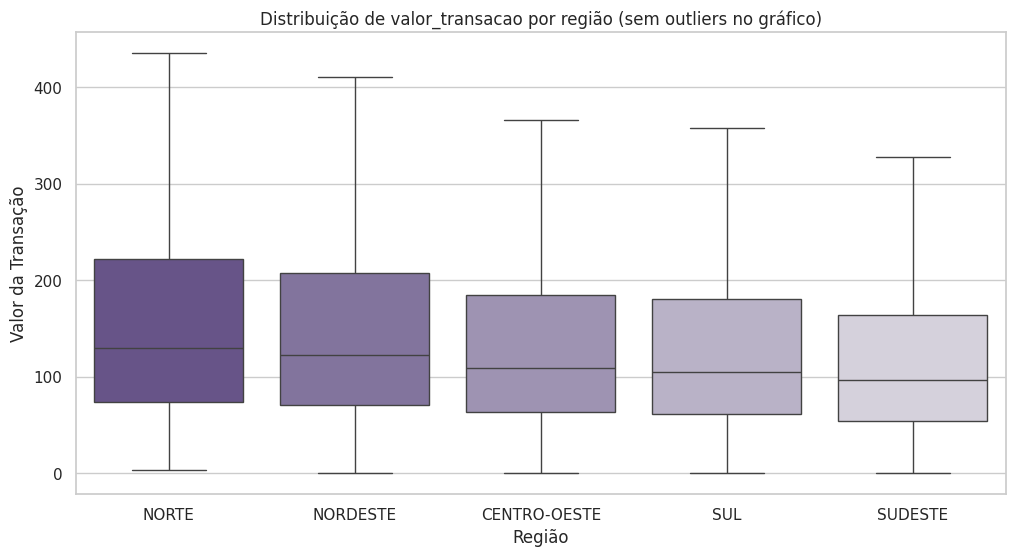

/tmp/ipykernel_1935/3141741466.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1935/3141741466.py:42: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(


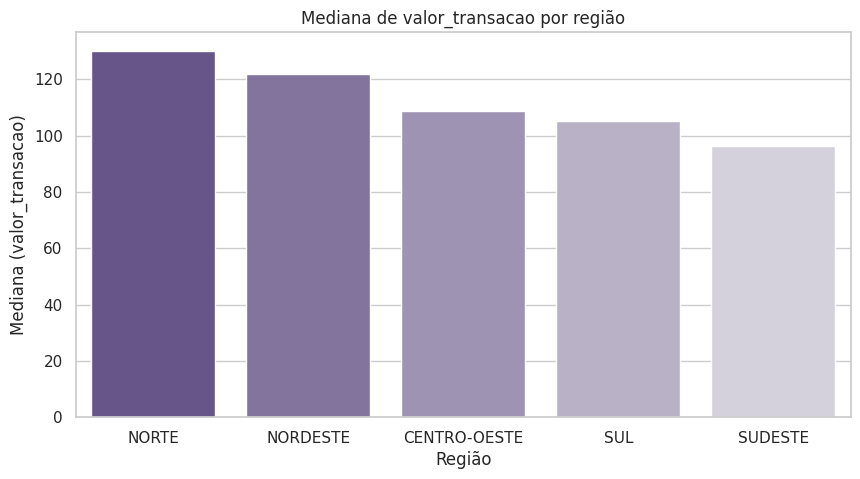

In [ ]:
# Hipótese 1: O valor da transação varia por região/estado?

cols_needed = {'valor_transacao', 'regiao', 'estado'}
missing = cols_needed - set(df.columns)
if missing:
    raise ValueError(f'Colunas ausentes no df: {missing}')

print('Resumo por REGIAO (valor_transacao):')
summary_regiao = (
    df.groupby('regiao')['valor_transacao']
      .agg(qtd='count', media='mean', mediana='median', p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
      .sort_values('mediana', ascending=False)
)
display(summary_regiao)

print('\nTop 10 ESTADOS por mediana de valor_transacao (com n>=100):')
summary_estado = (
    df.groupby('estado')['valor_transacao']
      .agg(qtd='count', media='mean', mediana='median')
      .query('qtd >= 100')
      .sort_values('mediana', ascending=False)
      .head(10)
)
display(summary_estado)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='regiao',
    y='valor_transacao',
    showfliers=False,
    order=summary_regiao.index,
    palette= sns.light_palette("#644c90", reverse= True)
)
plt.title('Distribuição de valor_transacao por região (sem outliers no gráfico)')
plt.xlabel('Região')
plt.ylabel('Valor da Transação')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary_regiao.reset_index(),
    x='regiao',
    y='mediana',
    order=summary_regiao.index,
    palette= sns.light_palette("#644c90", reverse= True)
)
plt.title('Mediana de valor_transacao por região')
plt.xlabel('Região')
plt.ylabel('Mediana (valor_transacao)')
plt.show()


Os boxplots corroboram diferenças de nível por região, com `NORTE` e `NORDESTE` apresentando distribuição deslocada para valores mais altos e `SUDESTE` com valores mais baixos, mas com sobreposição expressiva entre caixas.

No gráfico 2, ao olhar a mediana, a ordenação fica clara (aprox.: `NORTE` > `NORDESTE` > `CENTRO-OESTE` ≈ `SUL` > `SUDESTE`), com diferença visualmente relevante entre extremos.

## Hipótese 2

**O tipo de pagamento está associado a padrões de valor/preço transacionado??**

Evidências utilizadas:
- Scatterplots que comparam a relação entre `valor_transacao` e `preco_total` para cada variável categórica de `tipo_pagamento`


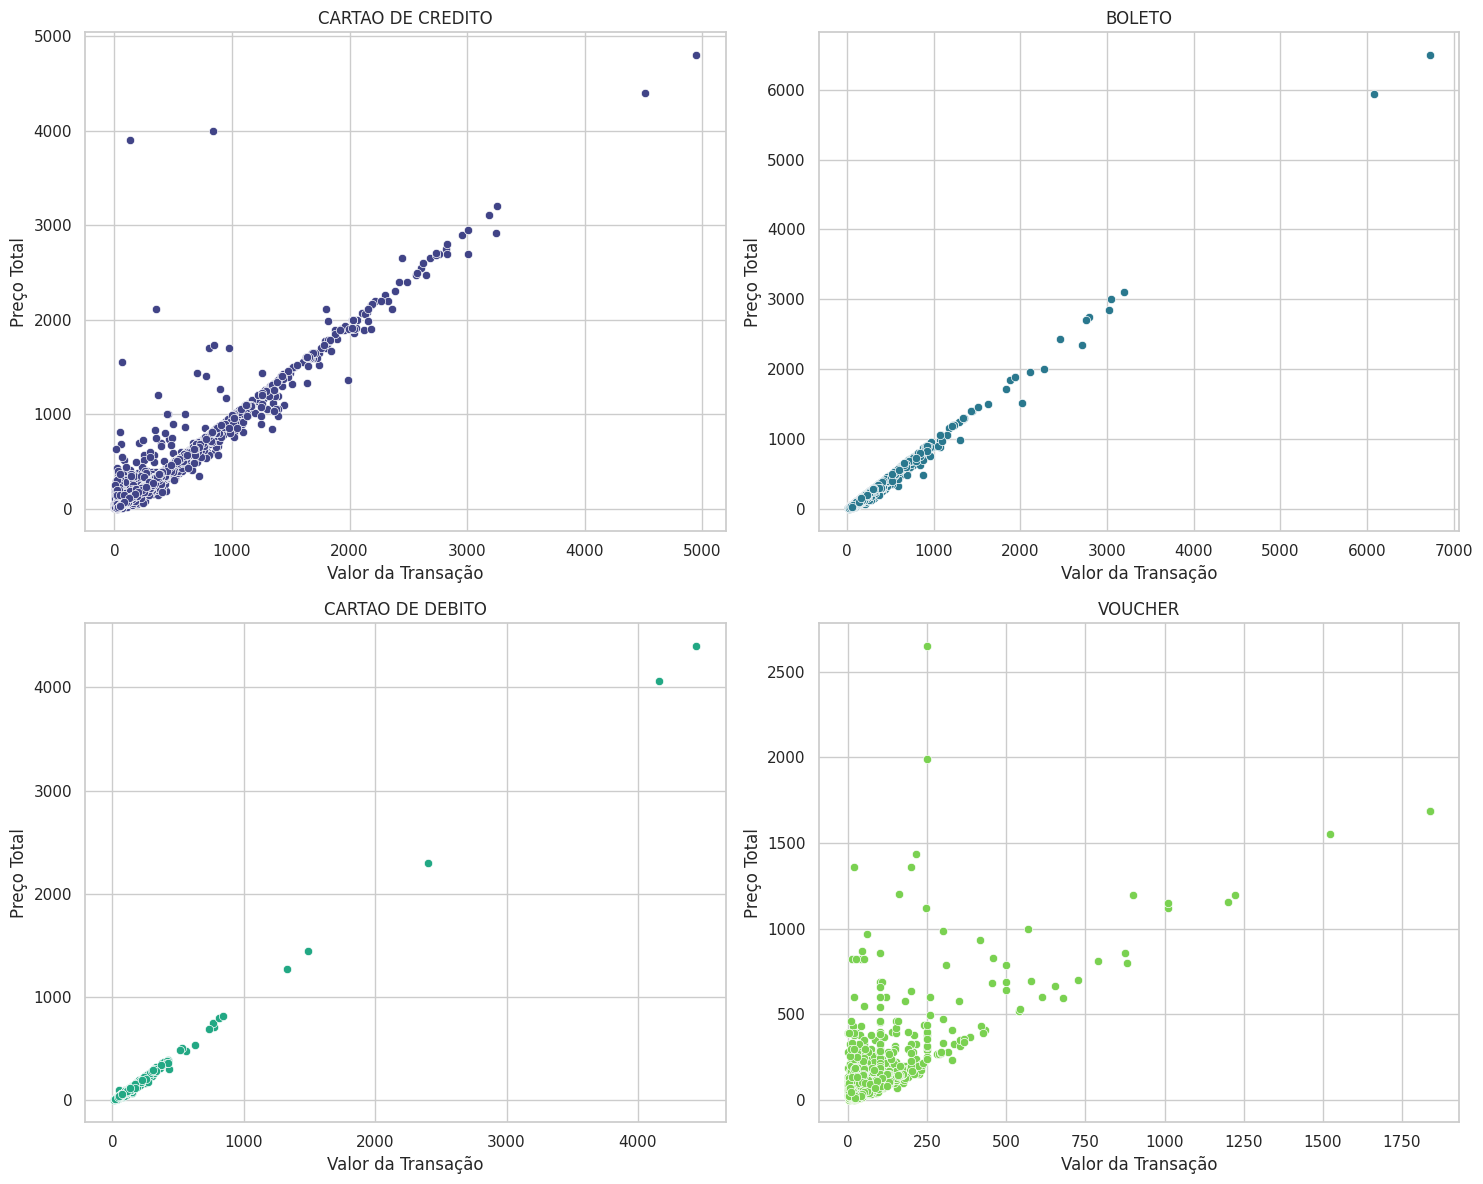

In [ ]:
# Hipótese 2: **O tipo de pagamento está associado a padrões de valor transacionado??**

# Tipos de pagamento únicos
payment_types = df['tipo_pagamento'].unique()
num_payment_types = len(payment_types)

# Tamanho dos subplots
rows = (num_payment_types + 1) // 2
cols = 2 if num_payment_types > 1 else 1

plt.figure(figsize=(15, 6 * rows))

# Coloração das observações
colors = sns.color_palette("viridis", num_payment_types)

for i, p_type in enumerate(payment_types):
    plt.subplot(rows, cols, i + 1)

    sns.scatterplot(data=df[df['tipo_pagamento'] == p_type], x='valor_transacao', y='preco_total', color=colors[i])
    plt.title(f'{p_type}')
    plt.xlabel('Valor da Transação')
    plt.ylabel('Preço Total')

plt.tight_layout()
plt.show()

Para CARTAO DE CREDITO e BOLETO, a relação entre `valor_transacao` e `preco_total` é bastante linear e direta, com a maioria dos pontos seguindo uma linha diagonal, indicando que o valor da transação e o preço total são muito semelhantes. Há uma concentração maior de transações em valores mais baixos, mas com uma cauda se estendendo para valores mais altos.

No que diz respeito à categoria CARTAO DE DEBITO, o padrão é similar, mas com um volume menor de transações e uma concentração ainda maior em valores mais baixos. A relação linear persiste, mas a dispersão é um pouco menor.

Na categoria VOUCHER, as transações estão predominantemente concentradas em valores mais baixos, com uma menor dispersão e poucos pontos em faixas de valores mais altas. Isso sugere que vouchers são mais frequentemente utilizados para compras de menor valor.

Dessa forma, a análise desses gráficos reforça que, embora haja uma forte correlação linear entre `valor_transacao` e `preco_total` em todos os tipos de pagamento, o tipo de pagamento está associado a diferentes faixas de valores transacionados e dispersão, especialmente com VOUCHER tendendo a transações de menor valor e CARTAO DE CREDITO abrangendo uma gama maior de valores.

## Hipótese 3

**Há relação entre variáveis numéricas e o `status_pedido`?**

Evidências utilizadas:
- `df.corr(numeric_only=True)` + heatmap
- scatterplot entre `valor_transacao` e `preco_total` (colorido por `regiao`)
- resumo por `status_pedido` (groupby)


Resumo por status_pedido (variáveis numéricas):


valor_transacao                                               \
                        count         mean         std      min        25%   
status_pedido                                                                
APROVADO                  1.0   179.460000         NaN   179.46   179.4600   
CANCELADO               136.0   220.441912  350.022848     9.46    62.7525   
ENTREGUE              29780.0   153.630647  211.663383     0.00    57.5100   
ENVIADO                 374.0   160.382273  242.016417     0.32    54.2100   
FATURADO                 83.0   232.096867  328.706190     9.23    82.8700   
INDISPONIVEL              1.0  1227.780000         NaN  1227.78  1227.7800   
PROCESSAMENTO            98.0   274.402347  301.200064     0.17    68.1825   

                                            preco_total               ...  \
                    50%        75%      max       count         mean  ...   
status_pedido                                                         ...   
APROVADO        179.460   179.4600   179.46         1.0   169.900000  ...   
CANCELADO       132.415   243.8175  2442.82       136.0   221.455368  ...   
ENTREGUE        100.470   172.3300  6726.66     29780.0   137.263897  ...   
ENVIADO          93.180   171.0550  2360.42       374.0   151.044037  ...   
FATURADO        132.570   249.4750  1827.72        83.0   212.839398  ...   
INDISPONIVEL   1227.780  1227.7800  1227.78         1.0  1199.000000  ...   
PROCESSAMENTO   146.405   351.9125  1426.81        98.0   247.717347  ...   

                                  frete_total                               \
                     75%      max       count       mean        std    min   
status_pedido                                                                
APROVADO        169.9000   169.90         1.0   9.560000        NaN   9.56   
CANCELADO       219.7000  2649.00       136.0  22.922941  22.008565   7.73   
ENTREGUE        149.9000  6499.00     29780.0  22.894557  20.648347   0.00   
ENVIADO         156.4925  2150.00       374.0  25.116364  23.964331   0.00   
FATURADO        212.4450  1775.90        83.0  23.185904  20.880866   7.42   
INDISPONIVEL   1199.0000  1199.00         1.0  28.780000        NaN  28.78   
PROCESSAMENTO   329.6750  1299.99        98.0  36.062857  58.956354   9.28   

                                                 
                   25%     50%      75%     max  
status_pedido                                    
APROVADO        9.5600   9.560   9.5600    9.56  
CANCELADO      12.2825  16.350  24.8525  171.88  
ENTREGUE       13.9300  17.315  24.3175  626.64  
ENVIADO        14.1550  18.345  25.9700  262.72  
FATURADO       13.0750  16.110  25.8800  131.19  
INDISPONIVEL   28.7800  28.780  28.7800   28.78  
PROCESSAMENTO  14.5550  16.995  26.4725  374.28  

[7 rows x 24 columns]

/tmp/ipykernel_1935/3639790349.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status_pedido', y=col, order=order, showfliers=False, palette= sns.light_palette("#644c90", reverse= True))
/tmp/ipykernel_1935/3639790349.py:20: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x='status_pedido', y=col, order=order, showfliers=False, palette= sns.light_palette("#644c90", reverse= True))


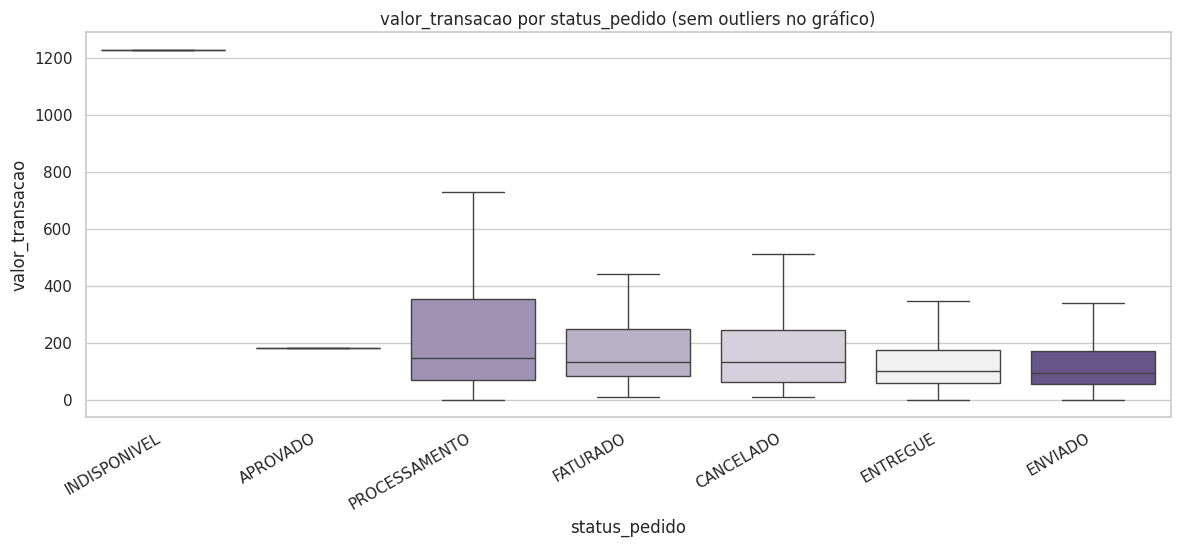

/tmp/ipykernel_1935/3639790349.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status_pedido', y=col, order=order, showfliers=False, palette= sns.light_palette("#644c90", reverse= True))
/tmp/ipykernel_1935/3639790349.py:20: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x='status_pedido', y=col, order=order, showfliers=False, palette= sns.light_palette("#644c90", reverse= True))


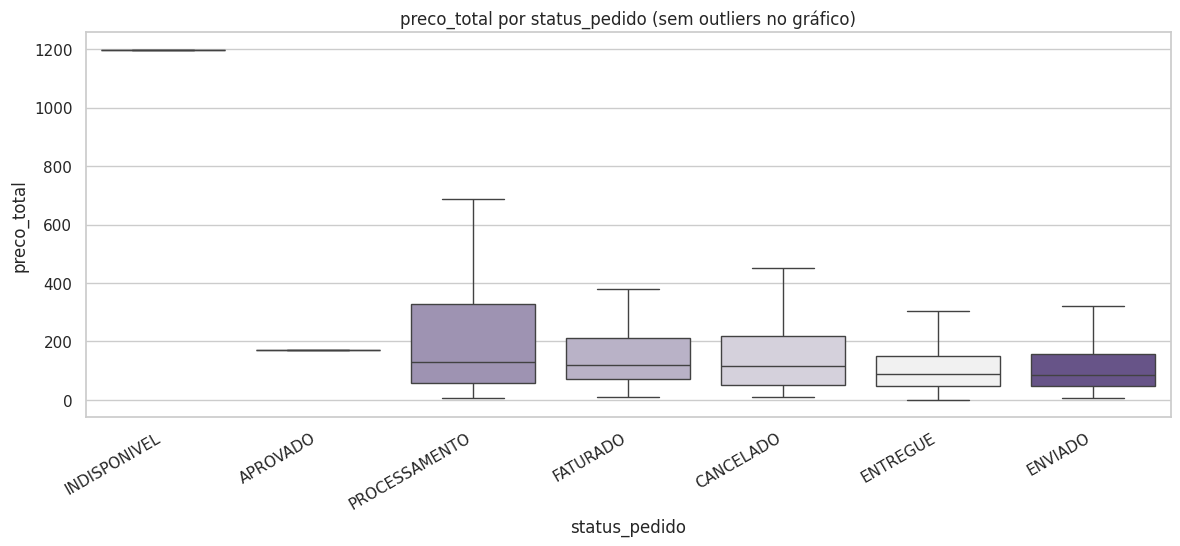

/tmp/ipykernel_1935/3639790349.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status_pedido', y=col, order=order, showfliers=False, palette= sns.light_palette("#644c90", reverse= True))
/tmp/ipykernel_1935/3639790349.py:20: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x='status_pedido', y=col, order=order, showfliers=False, palette= sns.light_palette("#644c90", reverse= True))


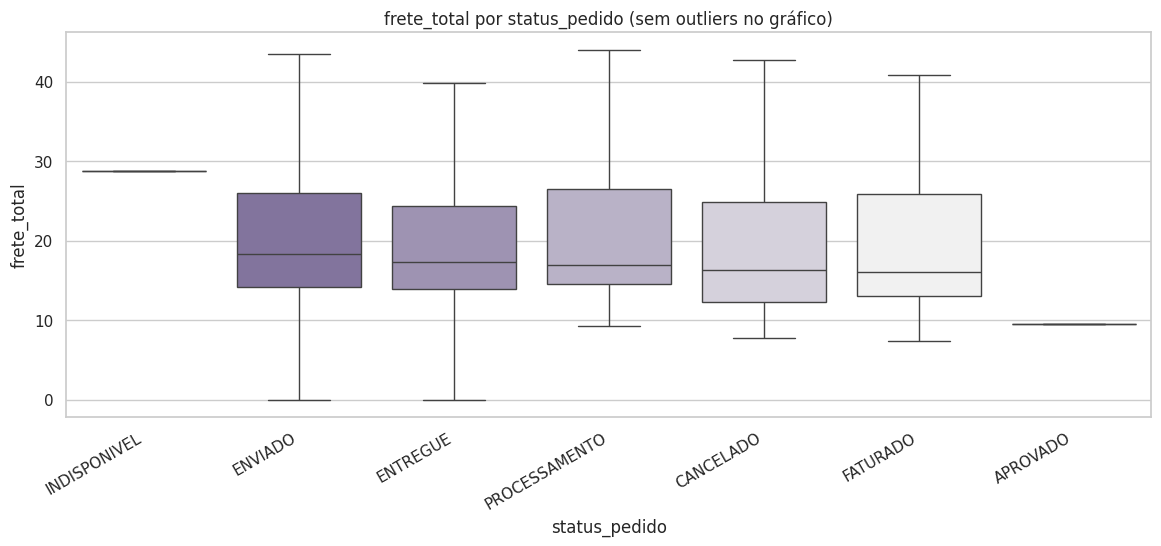

In [ ]:
# Hipótese 3: Há relação entre variáveis numéricas e o status_pedido?

cols_needed = {'status_pedido', 'valor_transacao', 'preco_total', 'frete_total'}
missing = cols_needed - set(df.columns)
if missing:
    raise ValueError(f'Colunas ausentes no df: {missing}')

print('Resumo por status_pedido (variáveis numéricas):')
summary_status = (
    df.groupby('status_pedido')[['valor_transacao','preco_total','frete_total']]
      .describe()
)
display(summary_status)

# Boxplots por status
for col in ['valor_transacao','preco_total','frete_total']:
    plt.figure(figsize=(14, 5))
    order = df.groupby('status_pedido')[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='status_pedido', y=col, order=order, showfliers=False, palette= sns.light_palette("#644c90", reverse= True))
    plt.title(f'{col} por status_pedido (sem outliers no gráfico)')
    plt.xlabel('status_pedido')
    plt.ylabel(col)
    plt.xticks(rotation=30, ha='right')
    plt.show()


Na primeira visualização, a variável `PROCESSAMENTO` aparece com maior mediana e maior variabilidade, enquanto `ENTREGUE` tende a valores menores; alguns status parecem ter pouquíssimas observações (linhas quase “pontuais”), o que limita inferências. **Pontos de atenção:** antes de concluir, filtre status com `n` mínimo (ex.: `n>=50`) ou reporte intervalos de confiança.

No gráfico 2, o comportamento acompanha `valor_transacao` (esperado pela alta correlação), com `PROCESSAMENTO` exibindo maior dispersão e patamar superior. **Ponto de atenção:** como `preco_total` é altamente redundante com `valor_transacao`, os dois gráficos podem contar a mesma história — para modelagem/interpretação, considere escolher apenas uma variável.

No último gráfico, as medianas de `frete_total` variam menos entre status (faixa mais estreita), sugerindo que o frete é menos determinante para diferenciar status do que o valor total. **Pontos de atenção:** verifique a presença de frete zero/ausente e políticas de frete (grátis por campanha), pois isso pode gerar subgrupos artificiais.

# Conclusão

O notebook consolidou um fluxo reprodutível de **EDA + pré-processamento** para o dataset do projeto 100cep_gateway, executando no **Google Colab** e carregando dados via **Databricks SQL API**.

Principais pontos aplicados:
- Definição clara de `X` e `y` (`tipo_pagamento`);
- Split estratificado e remoção de classes raras;
- Tratamento de outliers com decisão de **DROP somente no treino** (evitando vazamento);
- Pré-processamento final com `Pipeline` + `ColumnTransformer` (imputação + escala + one-hot).

Próximos passos naturais seriam treinar e avaliar um modelo de classificação usando `X_train_prepared`/`X_test_prepared`.
